# E22 · Many correlated outcomes: full covariance, factor models and copulas

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Daily returns of the 12 (and 30) US industry portfolios of the Kenneth R. French Data Library (CRSP), 2000-2024: fit on 2015-2019, test on 2020-2024 |
| **You will learn** | Volatility standardisation so that a static joint model is sensible · `pm.MvNormal` with `pm.LKJCholeskyCov` and what the LKJ prior says in 12 dimensions · why a full covariance costs $d(d-1)/2$ parameters · Bayesian factor analysis as low-rank + diagonal covariance · the three symmetries of a factor model (sign flips, rotations, column swaps) and what each does to r_hat · two fixes: an anchored lower-triangular constraint and post-hoc Procrustes alignment · choosing the number of factors by held-out log predictive density and LOO · when a factor model beats the full covariance (the ratio of days to dimensions) · a Gaussian copula with Student-t margins written by hand in PyMC · a multivariate Student-t and tail dependence · backtesting Value-at-Risk and "many industries crash together" on 2020-2024 |

A risk manager holds all twelve US industries. Twelve good models of one industry each do not
answer her questions: *what is the 1% worst day for the whole book?* and *how often do nine or
more industries crash on the same day?* Both depend on the **joint** distribution: on how the
industries move together, and on whether they move together *more* in a crash than on an
ordinary day.

This notebook builds that joint distribution in three steps, each with an honest failure:

1. a **full covariance** (`LKJCholeskyCov`): flexible, but the parameter count grows with the
   square of the dimension;
2. a **factor model**: a few common shocks plus industry-specific noise. It has few parameters,
   but it is not identified, and the symmetries break the sampler's diagnostics in instructive ways;
3. a **copula**: keep the dependence, but give each industry heavy-tailed (Student-t) margins.

Finally the three are tested out of sample on 2020-2024, a period with a pandemic crash and a
bear market in it.

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from scipy import linalg, optimize, special, stats

from pymc_challenges import data

RANDOM_SEED = 1987  # the year of Black Monday
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many small fits: silence the per-fit banner
# r_hat of the constant diagonal of a correlation matrix is 0/0: harmless
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide")
# we count high Pareto k values ourselves in section 4
warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Data: twelve industries, and a daily volatility filter

The French Data Library assigns every CRSP stock to an industry and publishes daily returns of
the resulting portfolios. The 12-industry file has two blocks, value-weighted and then
equal-weighted, each introduced by a line of text. We keep the value-weighted block: the rows
before the first index entry that is not an 8-digit date.

In [2]:
data.describe("ff_industries12_daily")


def industry_returns(name, start="2000-01-01"):
    raw = data.load(name)
    idx = raw.index.astype(str).str.strip()
    first_text_row = int(np.argmin(idx.str.fullmatch(r"\d{8}")))
    vw = raw.iloc[:first_text_row].apply(pd.to_numeric)
    vw.index = pd.to_datetime(idx[:first_text_row], format="%Y%m%d")
    vw.columns = vw.columns.str.strip()
    vw = vw.loc[start:]
    assert (vw > -99).all().all(), "missing values (-99.99) in the window"
    return vw


returns = industry_returns("ff_industries12_daily")
INDUSTRIES = list(returns.columns)
d = len(INDUSTRIES)
LABELS = {"NoDur": "consumer non-durables", "Durbl": "consumer durables", "Manuf": "manufacturing",
          "Enrgy": "oil, gas, coal", "Chems": "chemicals", "BusEq": "business equipment (tech)",
          "Telcm": "telecom", "Utils": "utilities", "Shops": "wholesale and retail",
          "Hlth": "healthcare", "Money": "finance", "Other": "everything else"}
print(f"{len(returns)} trading days, {returns.index[0]:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d}, d = {d}")
returns.tail(3)

ff_industries12_daily: Daily % returns of 12 US industry portfolios since July 1926 (NoDur ... Other). The file holds TWO blocks, value-weighted then equal-weighted, each headed by a text line: keep the rows before the first non-date index. -99.99 marks missing.
  source: Kenneth R. French Data Library (Fama & French, CRSP), 12 industry portfolios; updated monthly.
  url:    https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/12_Industry_Portfolios_daily_CSV.zip
6684 trading days, 2000-01-03 to 2026-07-31, d = 12


,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other
2026-07-29,0.24,-2.69,-4.38,2.37,-1.04,-1.84,-0.89,-1.06,-0.63,-0.60,-1.89,-0.79
2026-07-30,-2.22,2.52,3.93,0.75,-0.52,3.21,-2.28,-0.39,0.56,-1.50,0.60,0.35
2026-07-31,-1.26,0.32,0.31,0.81,-0.49,0.61,0.53,-0.36,5.68,-0.81,-0.14,-0.49


Daily returns are not independent draws from a fixed distribution. Their **volatility
clusters**: calm months, then weeks in which every day moves 3%. A static joint model fitted to
raw returns would average the calm and the storm and be wrong in both. The standard fix, and
the one we use, is to divide each return by a volatility forecast made **the day before**. Here
that is RiskMetrics' exponentially weighted moving average,

$$
s_{i,t}^2 = 0.94\, s_{i,t-1}^2 + 0.06\, r_{i,t-1}^2, \qquad z_{i,t} = r_{i,t} / s_{i,t}.
$$

The $z_{i,t}$ are "returns in units of yesterday's expected volatility". Everything below models
the vector $z_t$ of the 12 industries as independent draws from one joint distribution, and a
forecast for day $t$ multiplies back by the (known) $s_{i,t}$. This is the constant-correlation
idea of Bollerslev (1990) with the simplest possible volatility model. It is a real limitation,
and section 6 will show where it bites.

train 1258 days (2015-2019), test 1258 days (2020-2024)


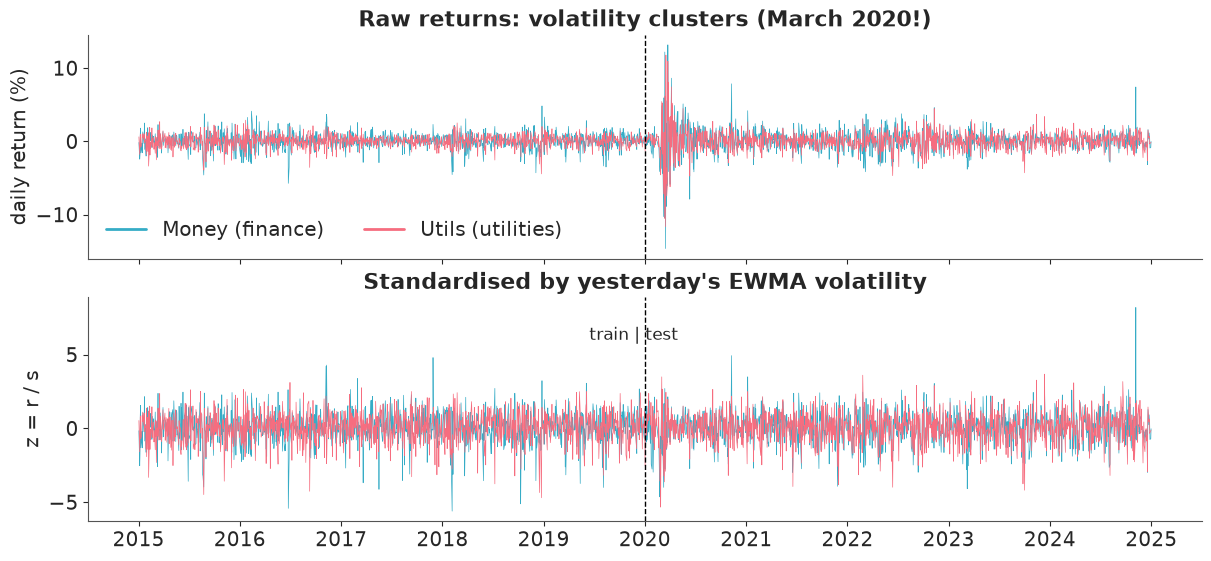

In [3]:
ewma_var = returns.pow(2).ewm(alpha=0.06, adjust=False).mean().shift(1)
vol = np.sqrt(ewma_var)                     # s_{i,t}: known at the close of day t-1
z = (returns / vol).loc["2005":]            # five years of burn-in for the filter

TRAIN, TEST = slice("2015-01-01", "2019-12-31"), slice("2020-01-01", "2024-12-31")
Z_train, Z_test = z.loc[TRAIN].to_numpy(), z.loc[TEST].to_numpy()
R_test, S_test = returns.loc[TEST].to_numpy(), vol.loc[TEST].to_numpy()
n_train, n_test = len(Z_train), len(Z_test)
print(f"train {n_train} days (2015-2019), test {n_test} days (2020-2024)")

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
for col, c in [("Money", "C0"), ("Utils", "C1")]:
    axes[0].plot(returns.loc["2015":"2024", col], lw=0.5, color=c, label=f"{col} ({LABELS[col]})")
    axes[1].plot(z.loc["2015":"2024", col], lw=0.5, color=c)
axes[0].set(ylabel="daily return (%)", title="Raw returns: volatility clusters (March 2020!)")
axes[1].set(ylabel="z = r / s", title="Standardised by yesterday's EWMA volatility")
for ax in axes:
    ax.axvline(pd.Timestamp("2020-01-01"), color="k", ls="--", lw=1)
for line in axes[0].legend(loc="lower left", ncol=2).get_lines():
    line.set_linewidth(2)
axes[1].annotate("train | test", (pd.Timestamp("2020-01-01"), 6), xytext=(-40, 0),
                 textcoords="offset points");

In [4]:
summary_tbl = pd.DataFrame({
    "sd raw (%)": returns.loc[TRAIN].std(),
    "excess kurtosis raw": stats.kurtosis(returns.loc[TRAIN]),
    "sd z": z.loc[TRAIN].std(),
    "excess kurtosis z": stats.kurtosis(Z_train),
    "excess kurtosis z (test)": stats.kurtosis(Z_test),
}).round(2)
summary_tbl

,sd raw (%),excess kurtosis raw,sd z,excess kurtosis z,excess kurtosis z (test)
NoDur,0.75,1.85,1.04,2.41,1.94
Durbl,1.18,1.64,1.04,1.62,3.39
Manuf,1.00,2.22,1.04,2.50,0.77
Enrgy,1.40,1.41,1.03,1.13,2.52
Chems,0.85,2.09,1.04,1.81,0.98
BusEq,1.09,2.98,1.05,3.65,0.89
Telcm,0.87,2.21,1.05,3.29,1.62
Utils,0.84,1.93,1.03,1.29,1.48
Shops,0.90,3.53,1.04,2.33,1.43
Hlth,1.01,2.22,1.04,1.76,0.84


The filter does its job on the scale (every `sd z` is close to 1) and removes a good part of the
fat tails, but not all of them: the standardised returns still have excess kurtosis of roughly
1-5 (a Normal has 0). Remember that for section 5.

The dependence is strong. Below is the correlation matrix of the training $z$: every pair is
positively correlated, half of the pairs above 0.6, and utilities are the odd one out.

pairwise correlations: min 0.18, median 0.61, max 0.90


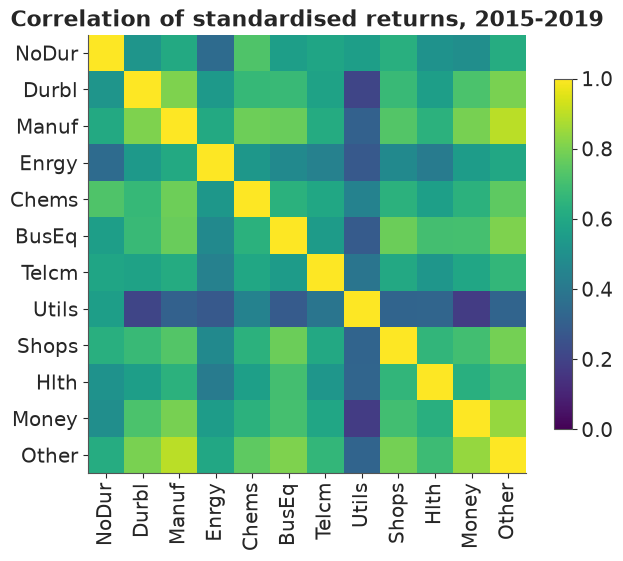

In [5]:
C_train = np.corrcoef(Z_train.T)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(C_train, vmin=0, vmax=1, cmap="viridis")
ax.set(xticks=range(d), yticks=range(d), title="Correlation of standardised returns, 2015-2019")
ax.set_xticklabels(INDUSTRIES, rotation=90)
ax.set_yticklabels(INDUSTRIES)
fig.colorbar(im, ax=ax, shrink=0.8)
off_diag = C_train[np.triu_indices(d, 1)]
print(f"pairwise correlations: min {off_diag.min():.2f}, median {np.median(off_diag):.2f}, max {off_diag.max():.2f}");

## 2 · A full covariance matrix with `LKJCholeskyCov`

The first model is a multivariate Normal with its own mean for each industry and an unrestricted
covariance matrix:

$$
z_t \sim \text{MvNormal}(\mu, \Sigma), \qquad \Sigma = \text{diag}(\sigma)\, \Omega\, \text{diag}(\sigma),
\qquad \Omega \sim \text{LKJ}(\eta = 2),\ \sigma_i \sim \text{HalfNormal}(1.5).
$$

(With predictors in the mean - one regression per industry, correlated errors - this is Zellner's
*seemingly unrelated regressions*. Nothing below changes.)

`pm.LKJCholeskyCov` samples the Cholesky factor of $\Sigma$ directly, which is what `MvNormal`
wants, and hands back the correlations and standard deviations as by-products.

**What does LKJ(2) say in 12 dimensions?** The marginal prior of each correlation under
LKJ($\eta$) in dimension $d$ is a Beta($\eta - 1 + d/2$, same) stretched to $(-1, 1)$. At
$d = 12$ that is Beta(7, 7): centred on zero with a standard deviation of about 0.27. The same
$\eta$ means a tighter prior in higher dimension, because a large matrix of big correlations is
hard to keep positive definite. Our data (a median correlation of 0.6, from 1258 days) will
overrule it, but check the prior against the data before trusting that.

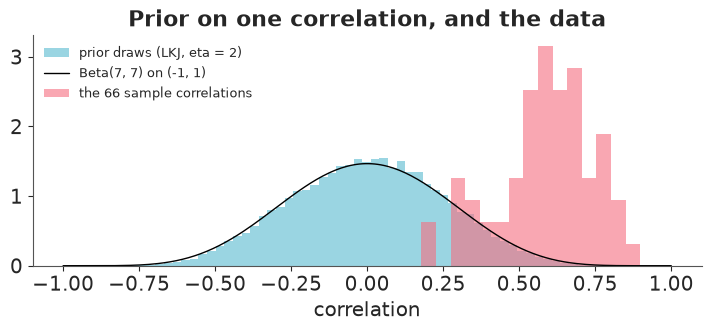

In [6]:
coords = {"industry": INDUSTRIES, "day": np.arange(n_train)}

with pm.Model(coords=coords) as mvn_model:
    mu = pm.Normal("mu", 0.0, 0.2, dims="industry")
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol", n=d, eta=2.0, sd_dist=pm.HalfNormal.dist(1.5), compute_corr=True
    )
    pm.MvNormal("z", mu, chol=chol, observed=Z_train, dims=("day", "industry"))

    prior = pm.sample_prior_predictive(draws=500, var_names=["chol_corr"], random_seed=RANDOM_SEED)

prior_corr = prior.prior["chol_corr"].values.reshape(-1, d, d)[:, *np.triu_indices(d, 1)].ravel()
x = np.linspace(-1, 1, 200)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(prior_corr, bins=60, density=True, alpha=0.5, label="prior draws (LKJ, eta = 2)")
ax.plot(x, stats.beta(7, 7).pdf((x + 1) / 2) / 2, color="k", lw=1, label="Beta(7, 7) on (-1, 1)")
ax.hist(off_diag, bins=15, density=True, alpha=0.6, label="the 66 sample correlations")
ax.set(xlabel="correlation", title="Prior on one correlation, and the data")
ax.legend(fontsize=9);

The prior puts little mass where the data are, but it does not rule them out, and 1258
observations of a correlation are a lot of information (the sampling sd of a correlation of 0.7
is about 0.015). We fit.

In [7]:
t0 = time.time()
with mvn_model:
    idata_mvn = pm.sample(random_seed=RANDOM_SEED)
time_mvn = time.time() - t0
summ = az.summary(idata_mvn, var_names=["chol_corr", "chol_stds", "mu"])
summ = summ[summ["sd"] > 0]                   # drop the constant 1s on the diagonal
print(f"{time_mvn:.0f} s, divergences: {int(idata_mvn.sample_stats['diverging'].sum())}, "
      f"max r_hat {summ['r_hat'].max():.3f}, min ESS bulk {summ['ess_bulk'].min():.0f}")

post_corr = idata_mvn.posterior["chol_corr"].mean(("chain", "draw")).values
gap = (post_corr - C_train)[np.triu_indices(d, 1)]
print(f"posterior mean minus sample correlation: largest |gap| {np.abs(gap).max():.3f}, "
      f"average gap {gap.mean():+.4f}")

7 s, divergences: 0, max r_hat 1.007, min ESS bulk 584
posterior mean minus sample correlation: largest |gap| 0.023, average gap -0.0177


Clean, fast, and the posterior correlations sit within a few hundredths of the sample
correlations: the LKJ prior pulls them slightly towards zero, and the data win.

So why do anything else? Because of how the parameter count grows. A covariance matrix has
$d(d+1)/2$ free entries: 78 here, but tens of thousands for a stock universe, and the data per
parameter shrink accordingly.

In [8]:
pd.DataFrame(
    {"d": [3, 12, 30, 100, 500],
     "correlations d(d-1)/2": [d_ * (d_ - 1) // 2 for d_ in [3, 12, 30, 100, 500]],
     "3-factor model: 3d - 3 + d": [3 * d_ - 3 + d_ for d_ in [3, 12, 30, 100, 500]]}
).set_index("d")

,correlations d(d-1)/2,3-factor model: 3d - 3 + d
d,,
3,3,9
12,66,45
30,435,117
100,4950,397
500,124750,1997


With 500 stocks and five years of daily data (about 1260 days) the full covariance has 125,250
correlations against 630,000 numbers of data, and the sample covariance of 500 series from 1260
days is famously noisy. A **factor model** asks for $K$ loadings per series instead.

## 3 · The factor model and its symmetries

Suppose each day's returns are driven by $K$ common shocks $f_t$ (a "market" shock, a
"defensive versus cyclical" shock...) plus an industry-specific one:

$$
z_t = \mu + \Lambda f_t + \varepsilon_t, \qquad f_t \sim \text{Normal}(0, I_K),\quad
\varepsilon_t \sim \text{Normal}(0, \text{diag}(\psi^2)).
$$

$\Lambda$ is the $d \times K$ matrix of **loadings**. We never need the 1258 x $K$ latent
factors: integrating them out gives

$$
z_t \sim \text{MvNormal}\big(\mu,\ \Lambda\Lambda^\top + \text{diag}(\psi^2)\big),
$$

a covariance that is **low-rank plus diagonal**. NUTS then sees only $dK + 2d$ parameters.

The catch: $\Lambda\Lambda^\top = (\Lambda Q)(\Lambda Q)^\top$ for **any** orthogonal $K\times K$
matrix $Q$. Flipping the sign of a column, swapping two columns and rotating the columns all
leave the likelihood unchanged. With iid Normal priors on the loadings the prior is unchanged
too, so the posterior has exactly the same symmetry. The loadings are not identified; only
$\Lambda\Lambda^\top$ is.

In [9]:
def factor_model(K, Z=Z_train):
    """Unconstrained factor model: iid Normal loadings (rotation-invariant posterior)."""
    fcoords = {"industry": INDUSTRIES, "factor": [f"F{k + 1}" for k in range(K)], "day": np.arange(len(Z))}
    with pm.Model(coords=fcoords) as m:
        mu = pm.Normal("mu", 0.0, 0.2, dims="industry")
        L = pm.Normal("L", 0.0, 1.0, dims=("industry", "factor"))
        psi = pm.HalfNormal("psi", 1.0, dims="industry")
        Sigma = pm.Deterministic("Sigma", L @ L.T + pt.diag(psi**2))
        pm.MvNormal("z", mu, cov=Sigma, observed=Z, dims=("day", "industry"))
    return m

### 3.1 · One factor: the sign flip

With $K = 1$ the only symmetry is $\Lambda \to -\Lambda$. Two mirror-image modes, separated by
a wall of low probability (every loading would have to pass through zero at once). Each chain
picks one.

per-chain mean loading of Manuf: [ 0.97  0.97 -0.97 -0.98]
max r_hat: loadings 1.74, covariance entries 1.007


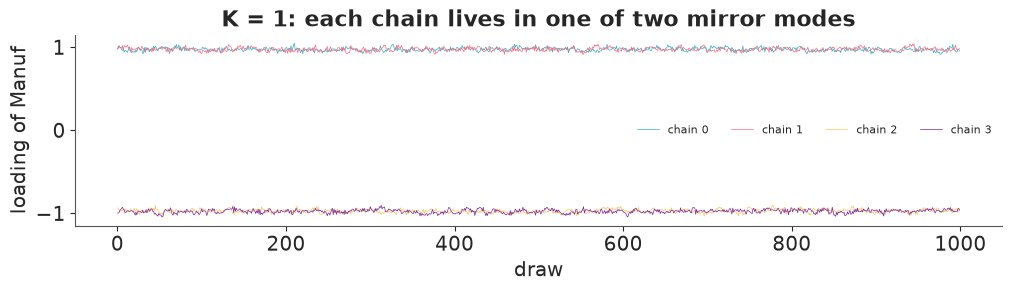

In [10]:
with factor_model(1):
    idata_k1 = pm.sample(random_seed=RANDOM_SEED)

L_k1 = idata_k1.posterior["L"]
print("per-chain mean loading of Manuf:", L_k1.sel(industry="Manuf").mean("draw").values.ravel().round(2))
print(f"max r_hat: loadings {float(az.rhat(L_k1).max()):.2f}, "
      f"covariance entries {float(az.rhat(idata_k1.posterior['Sigma']).max()):.3f}")

fig, ax = plt.subplots(figsize=(10, 2.8))
for c in range(L_k1.sizes["chain"]):
    ax.plot(L_k1.sel(industry="Manuf", chain=c).values.ravel(), lw=0.5, label=f"chain {c}")
ax.set(xlabel="draw", ylabel="loading of Manuf", title="K = 1: each chain lives in one of two mirror modes")
ax.legend(ncol=4, fontsize=8);

The loadings' r_hat is far above 1.01, yet nothing is wrong with the *model*: the covariance
entries have r_hat close to 1, because both modes imply the same $\Sigma$. Every prediction made
from this fit is fine. Only the loadings - the thing you would want to interpret - are a mixture
of two mirror images.

### 3.2 · Three factors: the rotation

With $K = 3$ the symmetry is continuous: the posterior is constant along a whole 3-dimensional
family of rotations. There is no wall to cross, so every chain **wanders around the orbit**.

In [11]:
t0 = time.time()
with factor_model(3):
    idata_k3 = pm.sample(random_seed=RANDOM_SEED)
time_k3 = time.time() - t0
L_k3 = idata_k3.posterior["L"]
print(f"{time_k3:.0f} s; loadings: max r_hat {float(az.rhat(L_k3).max()):.3f}, "
      f"min ESS {float(az.ess(L_k3).min()):.0f}; covariance: max r_hat "
      f"{float(az.rhat(idata_k3.posterior['Sigma']).max()):.3f}, min ESS {float(az.ess(idata_k3.posterior['Sigma']).min()):.0f}")
L_mu, L_sd = L_k3.mean(("chain", "draw")), L_k3.std(("chain", "draw"))
pd.DataFrame({f"{f} mean (sd)": [f"{L_mu.sel(industry=i, factor=f).item():+.2f} ({L_sd.sel(industry=i, factor=f).item():.2f})"
                                 for i in ["Manuf", "Utils", "Money"]] for f in L_k3.factor.values},
             index=["Manuf", "Utils", "Money"])

26 s; loadings: max r_hat 1.028, min ESS 186; covariance: max r_hat 1.002, min ESS 4084


,F1 mean (sd),F2 mean (sd),F3 mean (sd)
Manuf,+0.02 (0.58),-0.05 (0.57),-0.02 (0.57)
Utils,+0.01 (0.37),-0.03 (0.41),-0.03 (0.40)
Money,+0.01 (0.54),-0.05 (0.53),-0.01 (0.52)


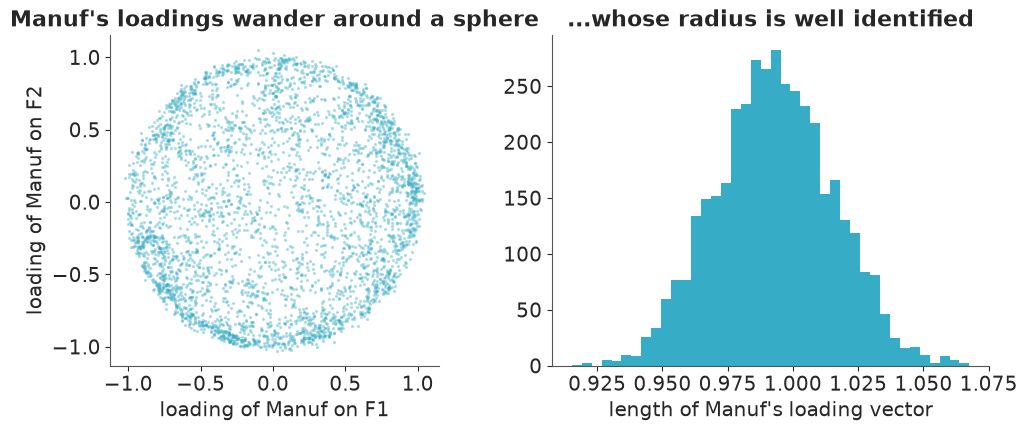

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
ax = axes[0]
draws = L_k3.sel(industry="Manuf").stack(s=("chain", "draw")).values
ax.scatter(draws[0], draws[1], s=2, alpha=0.3)
ax.set(xlabel="loading of Manuf on F1", ylabel="loading of Manuf on F2", aspect="equal",
       title="Manuf's loadings wander around a sphere")
ax = axes[1]
norm_manuf = np.sqrt((draws**2).sum(0))
ax.hist(norm_manuf, bins=40)
ax.set(xlabel="length of Manuf's loading vector", title="...whose radius is well identified");

This failure is quieter than the sign flip. Each chain explores the same rotation orbit, so r_hat
is only a little above 1 and nothing is flagged loudly. But every posterior mean of a loading is
near zero, and a table of them would say "no industry loads on any factor", which is absurd: the
length of Manuf's loading vector (right) is pinned near 1. The sampler also pays for the walk:
the loadings' ESS is low, and the fit takes several times longer than the full covariance model of
section 2 (compare the two timings printed above).

(A third symmetry, **column switching** - factors 1 and 2 swapping roles between chains - is the
$K > 1$ analogue of label switching in mixtures. It is one of the rotations, so the two fixes
below handle it too.)

### 3.3 · Fix 1: a lower-triangular constraint, done naively

The textbook fix (Geweke & Zhou 1996; Lopes & West 2004) removes the rotation by forcing
$\Lambda$ to be lower triangular with a positive diagonal: industry 1 loads only on factor 1,
industry 2 only on factors 1-2, and so on. That leaves $dK - K(K-1)/2$ loadings and, in
principle, one mode. Here it is with the industries in the file's order.

In [13]:
def lower_triangular_model(K, Z=Z_train):
    """Loadings lower triangular (rows in file order), positive diagonal."""
    with pm.Model() as m:
        mu = pm.Normal("mu", 0.0, 0.2, shape=d)
        n_free = d * K - K * (K + 1) // 2
        free = pm.Normal("L_free", 0.0, 1.0, shape=n_free)
        diag = pm.HalfNormal("L_diag", 1.0, shape=K)
        L, k = pt.zeros((d, K)), 0
        for j in range(K):
            L = pt.set_subtensor(L[j, j], diag[j])
            L = pt.set_subtensor(L[j + 1:, j], free[k:k + d - j - 1])
            k += d - j - 1
        pm.Deterministic("L", L)
        psi = pm.HalfNormal("psi", 1.0, shape=d)
        pm.MvNormal("z", mu, cov=L @ L.T + pt.diag(psi**2), observed=Z)
    return m


for K in [1, 3]:
    with lower_triangular_model(K):
        idata_lt = pm.sample(random_seed=RANDOM_SEED)
    diag_by_chain = idata_lt.posterior["L_diag"].mean("draw").values.round(2)
    print(f"K = {K}: anchors {INDUSTRIES[:K]}, r_hat of the diagonal "
          f"{az.rhat(idata_lt.posterior['L_diag']).values.round(2)}, per-chain means:\n{diag_by_chain}")
del idata_lt

K = 1: anchors ['NoDur'], r_hat of the diagonal [1.73], per-chain means:
[[0. ]
 [0.7]
 [0.7]
 [0. ]]


K = 3: anchors ['NoDur', 'Durbl', 'Manuf'], r_hat of the diagonal [1. 1. 1.], per-chain means:
[[0.94 0.65 0.01]
 [0.94 0.65 0.01]
 [0.94 0.65 0.01]
 [0.94 0.65 0.01]]


Two different failures:

* **$K = 1$.** Some chains have the NoDur loading at about 0.7 and others have it stuck at
  **zero**. The constraint did not delete the mirror mode; it made it a local mode on the boundary.
  A chain that starts with most loadings negative cannot flip all of them together, so it keeps
  the other eleven negative and pushes NoDur's loading to the nearest legal value, 0. NoDur's
  variance is then explained by its own noise $\psi$. That fits worse, but it is a trap all the
  same.
* **$K = 3$.** Manufacturing, the third anchor, gets a diagonal loading of about 0.01 in every chain. Its
  loadings lie almost in the plane spanned by the first two anchors (durables and manufacturing
  are both cyclical), so the constraint pins factor 3 to a direction that the data barely
  identify. r_hat is 1.00 here and notices nothing (with another seed, in our tests, one chain found
  0.05 instead and r_hat rose to 1.36). The model is "identified" only in name.

The constraint works when the **anchors** (the first $K$ rows) are well chosen, meaning that their
loading vectors are far from collinear, and when the chains start in the right basin.

### 3.4 · Fix 1, done properly: anchors from pivoted QR, chains started at the ML solution

1. Find the maximum-likelihood factor solution (15 lines of SciPy below).
2. Choose the anchors with a **pivoted QR** decomposition of $\hat\Lambda^\top$. It picks the
   industry with the longest loading vector, then the one most orthogonal to it, and so on. This
   is the standard way to pick well-conditioned rows.
3. Instead of reordering the data, impose the triangular pattern on the anchor rows wherever they
   are: anchor $j$ loads on factors $1..j$ only, positively on factor $j$.
4. Rotate $\hat\Lambda$ into that pattern and start every chain there, **without** nutpie's
   random jitter (`compile_kwargs={"jitter_rvs": set()}`).

In [14]:
S_train = np.cov(Z_train.T)


def ml_factor(K, S=S_train, n=n_train):
    """Maximum-likelihood factor analysis (Normal), returns loadings and uniquenesses psi^2."""
    dd = S.shape[0]
    w, V = np.linalg.eigh(S)
    V = V[:, ::-1] * np.sqrt(w[::-1])

    def nll(p):
        L = p[:dd * K].reshape(dd, K)
        Sig = L @ L.T + np.diag(np.exp(p[dd * K:]))
        return 0.5 * n * (np.linalg.slogdet(Sig)[1] + np.trace(np.linalg.solve(Sig, S)))

    p0 = np.r_[0.9 * V[:, :K].ravel(), np.log(np.full(dd, 0.3))]
    p = optimize.minimize(nll, p0, method="L-BFGS-B").x
    return p[:dd * K].reshape(dd, K), np.exp(p[dd * K:])


def choose_anchors(L_hat):
    return list(linalg.qr(L_hat.T, pivoting=True)[2][:L_hat.shape[1]])


def rotate_to_anchors(L_hat, anchors):
    """Orthogonal rotation making L[anchors] lower triangular with a positive diagonal."""
    q, _ = np.linalg.qr(L_hat[anchors].T)
    L_rot = L_hat @ q
    return L_rot * np.sign(np.diag(L_rot[anchors]))


def anchored_model(K, anchors, Z=Z_train, names=INDUSTRIES):
    dd = Z.shape[1]
    free_mask, pos_mask = np.ones((dd, K), bool), np.zeros((dd, K), bool)
    for j, a in enumerate(anchors):
        free_mask[a, j:] = False          # anchor j: nothing on factors after j ...
        pos_mask[a, j] = True             # ... and a positive loading on factor j
    free_idx, pos_idx = np.nonzero(free_mask), np.nonzero(pos_mask)
    fcoords = {"industry": names, "factor": [f"F{k + 1}" for k in range(K)], "day": np.arange(len(Z))}
    with pm.Model(coords=fcoords) as m:
        mu = pm.Normal("mu", 0.0, 0.2, dims="industry")
        free = pm.Normal("L_free", 0.0, 1.0, shape=len(free_idx[0]))
        pos = pm.HalfNormal("L_anchor", 1.0, shape=K)
        L = pt.set_subtensor(pt.zeros((dd, K))[free_idx], free)
        L = pm.Deterministic("L", pt.set_subtensor(L[pos_idx], pos), dims=("industry", "factor"))
        psi = pm.HalfNormal("psi", 1.0, dims="industry")
        pm.MvNormal("z", mu, cov=L @ L.T + pt.diag(psi**2), observed=Z, dims=("day", "industry"))
    return m, free_idx, pos_idx


def fit_anchored(K, Z=Z_train, names=INDUSTRIES, **kwargs):
    L_hat, psi2_hat = ml_factor(K, np.cov(Z.T), len(Z))
    anchors = choose_anchors(L_hat)
    L0 = rotate_to_anchors(L_hat, anchors)
    m, free_idx, pos_idx = anchored_model(K, anchors, Z, names)
    with m:
        idata = pm.sample(random_seed=RANDOM_SEED, compile_kwargs={"jitter_rvs": set()},
                          initvals={"L_free": L0[free_idx], "L_anchor": L0[pos_idx],
                                    "psi": np.sqrt(psi2_hat)}, **kwargs)
    return m, idata, anchors


t0 = time.time()
m_anch3, idata_anch3, anchors3 = fit_anchored(3)
time_anch3 = time.time() - t0
s_anch = az.summary(idata_anch3, var_names=["L_anchor", "L_free", "psi"])
print(f"anchors: {[INDUSTRIES[a] for a in anchors3]}; {time_anch3:.0f} s, "
      f"divergences {int(idata_anch3.sample_stats['diverging'].sum())}, max r_hat {s_anch['r_hat'].max():.3f}, "
      f"min ESS {s_anch['ess_bulk'].min():.0f}")
print("anchor loadings by chain:\n", idata_anch3.posterior["L_anchor"].mean("draw").values.round(2))

anchors: ['Other', 'NoDur', 'Shops']; 3 s, divergences 0, max r_hat 1.004, min ESS 623
anchor loadings by chain:
 [[0.65 0.28 1.02]
 [0.65 0.28 1.02]
 [0.65 0.28 1.02]
 [0.65 0.28 1.02]]


Now the fit is clean and fast, and all chains agree. Be clear about what was needed, though: a
data-driven choice of anchors **and** chains started in the right basin. With nutpie's default
jitter the same model sent some chains into boundary modes in our tests. r_hat cannot flag a
wrong basin that every chain shares, and with no jitter all four chains start at one point, so
agreement between them is weaker evidence than usual. That is the price of this fix.

### 3.5 · Fix 2: sample freely, align afterwards

The other fix leaves the sampler alone and deals with the symmetry after sampling. Since the
posterior of the unconstrained model is *exactly* invariant under $\Lambda \to \Lambda Q$, we may
rotate each draw by whatever $Q$ we like without changing the distribution of anything
identified. Choose a reference loading matrix $\Lambda_{\text{ref}}$ and rotate each draw to it
(an **orthogonal Procrustes** problem, one SVD per draw):

$$
Q_s = \arg\min_{Q^\top Q = I} \lVert \Lambda_s Q - \Lambda_{\text{ref}} \rVert_F = U V^\top,
\quad \text{where } \Lambda_s^\top \Lambda_{\text{ref}} = U D V^\top.
$$

For the reference we take the ML loadings after a **varimax** rotation: the rotation that makes
each column have a few large and many small loadings, the easiest to read. The reference only
chooses the coordinate system. The uncertainty comes from the draws.

In [15]:
def varimax(L, n_iter=200):
    p, k = L.shape
    R = np.eye(k)
    for _ in range(n_iter):
        LR = L @ R
        u, _, vt = np.linalg.svd(L.T @ (LR**3 - LR @ np.diag((LR**2).sum(0)) / p))
        R = u @ vt
    return L @ R


L_ref = varimax(ml_factor(3)[0])
L_ref = L_ref * np.sign(L_ref.sum(0))               # make each factor's loadings mostly positive
L_ref = L_ref[:, np.argsort(-(L_ref**2).sum(0))]    # order factors by explained variance


def procrustes_align(L_draws, L_ref):
    """Rotate every draw (..., d, K) to the reference (reflections allowed)."""
    u, _, vt = np.linalg.svd(np.swapaxes(L_draws, -1, -2) @ L_ref)
    return L_draws @ (u @ vt)


L_aligned = xr.DataArray(procrustes_align(L_k3.values, L_ref), coords=L_k3.coords, dims=L_k3.dims)
print(f"aligned loadings: max r_hat {float(az.rhat(L_aligned).max()):.3f}, "
      f"min ESS {float(az.ess(L_aligned).min()):.0f}   (before: r_hat {float(az.rhat(L_k3).max()):.3f}, "
      f"ESS {float(az.ess(L_k3).min()):.0f})")

aligned loadings: max r_hat 1.001, min ESS 3292   (before: r_hat 1.028, ESS 186)


The same draws that looked like noise now have r_hat about 1.00 and an ESS in the thousands. The
sampler had been exploring the posterior of the identified quantities perfectly well all along;
the loadings only needed a common coordinate system. The unconstrained fit and the anchored fit
are also the same model up to rotation (their loadings live in different coordinates). Rotating
the anchored draws to the same reference gives the same picture:

max |difference| of posterior mean aligned loadings, unconstrained vs anchored: 0.002


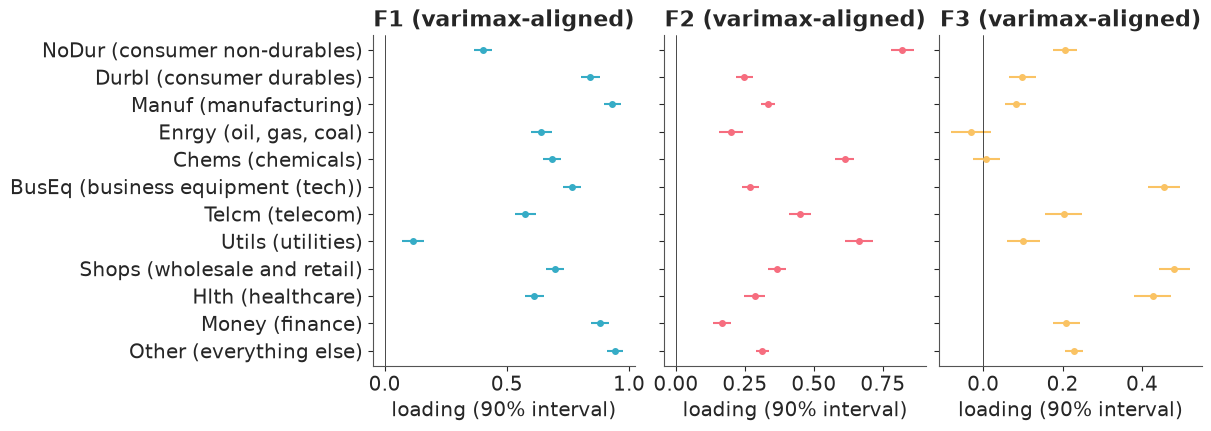

In [16]:
L_anch_aligned = procrustes_align(idata_anch3.posterior["L"].values, L_ref)
print(f"max |difference| of posterior mean aligned loadings, unconstrained vs anchored: "
      f"{np.abs(L_aligned.mean(('chain', 'draw')).values - L_anch_aligned.mean((0, 1))).max():.3f}")

q = L_aligned.quantile([0.05, 0.5, 0.95], dim=("chain", "draw")).values   # (3, d, K)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
names = ["F1", "F2", "F3"]
for k, ax in enumerate(axes):
    ax.errorbar(q[1, :, k], np.arange(d), xerr=[q[1, :, k] - q[0, :, k], q[2, :, k] - q[1, :, k]],
                fmt="o", ms=4, color=f"C{k}")
    ax.axvline(0, color="k", lw=0.5)
    ax.set(title=f"{names[k]} (varimax-aligned)", xlabel="loading (90% interval)")
axes[0].set(yticks=range(d), yticklabels=[f"{c} ({LABELS[c]})" for c in INDUSTRIES])
axes[0].invert_yaxis();

Read the columns (the numbers are loadings on standardised returns, so 0.9 means the factor
carries most of that industry's daily variance):

* **F1, the cyclical market.** Manufacturing, finance, durables, business equipment and
  "other" load at 0.75-0.95. Utilities barely load at all.
* **F2, defensives.** Utilities, consumer non-durables and chemicals (a sector that includes
  household products) load strongly, cyclicals weakly. On days when F2 is up, safe havens move
  together.
* **F3, growth and consumer-facing.** Business equipment (tech), wholesale/retail and healthcare
  load at about 0.4-0.5, energy at zero.

Varimax is a *choice*: any rotation of these three columns fits equally well. "Market /
defensive / growth" is a helpful description, not a discovery, and the fact that the posterior
supports it is only a statement about this coordinate system.

## 4 · How many factors?

$K$ is a modelling choice with a predictive answer. We compare, on the **held-out 2020-2024
data**, the log predictive density of each day's 12-vector:

$$
\text{lpd}_t = \log \frac{1}{S} \sum_{s=1}^S \text{MvNormal}(z_t \mid \mu_s, \Sigma_s),
$$

summed over the 1258 test days. Predictive quantities only need $\Sigma$, which is identified,
so we can use the fast anchored fits. We also compute PSIS-LOO on the training days for
comparison. Rows of a daily time series are not exchangeable, so LOO here measures "predict a
random missing day", not "predict next year".

In [17]:
def lpd_mvnormal(mu_draws, Sigma_draws, Z):
    """Per-day log predictive density, averaging the density over posterior draws."""
    lp = np.stack([stats.multivariate_normal(m_, S_).logpdf(Z) for m_, S_ in zip(mu_draws, Sigma_draws)])
    return special.logsumexp(lp, axis=0) - np.log(len(lp))


def factor_draws(idata, n=400):
    post = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED)
    L, psi = post["L"].transpose("sample", ...).values, post["psi"].transpose("sample", ...).values
    Sigma = L @ np.swapaxes(L, 1, 2) + psi[:, :, None] ** 2 * np.eye(L.shape[1])
    return post["mu"].transpose("sample", ...).values, Sigma


def full_draws(idata, n=400):
    post = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED)
    sd = post["chol_stds"].transpose("sample", ...).values
    corr = post["chol_corr"].transpose("sample", ...).values
    return post["mu"].transpose("sample", ...).values, sd[:, :, None] * corr * sd[:, None, :]


def loo_of(model, idata):
    with model:
        pm.compute_log_likelihood(idata, progressbar=False)
    res = az.loo(idata, pointwise=True)
    res.n_high_k = int((res.pareto_k > 0.7).sum())
    res.log_weights = None                 # the weight matrix is big and not needed
    del idata["log_likelihood"]
    return res


heldout, loos, fit_times = {}, {}, {}

# K = 0: independent Normals (no dependence at all), written as an MvNormal with a diagonal
# covariance so that its log-likelihood is per day, like the others
with pm.Model(coords=coords) as diag_model:
    mu0 = pm.Normal("mu", 0.0, 0.2, dims="industry")
    sd0 = pm.HalfNormal("sd", 1.5, dims="industry")
    pm.MvNormal("z", mu0, cov=pt.diag(sd0**2), observed=Z_train, dims=("day", "industry"))
    idata_diag = pm.sample(random_seed=RANDOM_SEED)
post0 = az.extract(idata_diag, num_samples=400, random_seed=RANDOM_SEED)
lp0 = stats.norm.logpdf(Z_test[None], post0["mu"].values.T[:, None], post0["sd"].values.T[:, None]).sum(-1)
heldout["K=0 (independent)"] = special.logsumexp(lp0, 0) - np.log(400)
loos["K=0 (independent)"] = loo_of(diag_model, idata_diag)
del idata_diag

for K in range(1, 7):
    t0 = time.time()
    if K == 3:
        m_K, idata_K = m_anch3, idata_anch3
    else:
        m_K, idata_K, _ = fit_anchored(K)
    fit_times[K] = time.time() - t0
    s_K = az.summary(idata_K, var_names=["L_anchor", "L_free", "psi"])
    print(f"K = {K}: divergences {int(idata_K.sample_stats['diverging'].sum()):3d}, "
          f"max r_hat {s_K['r_hat'].max():.3f}, min ESS {s_K['ess_bulk'].min():5.0f}")
    heldout[f"K={K}"] = lpd_mvnormal(*factor_draws(idata_K), Z_test)
    loos[f"K={K}"] = loo_of(m_K, idata_K)
    if K != 3:
        del idata_K

heldout["full (LKJ)"] = lpd_mvnormal(*full_draws(idata_mvn), Z_test)
loos["full (LKJ)"] = loo_of(mvn_model, idata_mvn)

K = 1: divergences   0, max r_hat 1.007, min ESS   683


K = 2: divergences   0, max r_hat 1.003, min ESS   659


K = 3: divergences   0, max r_hat 1.004, min ESS   623


K = 4: divergences  42, max r_hat 1.043, min ESS   120


K = 5: divergences  56, max r_hat 1.046, min ESS    79


K = 6: divergences   3, max r_hat 1.034, min ESS    98


In [18]:
best = "full (LKJ)"
k_table = pd.DataFrame({
    "parameters": [2 * d] + [2 * d + d * K - K * (K - 1) // 2 for K in range(1, 7)] + [2 * d + d * (d - 1) // 2],
    "held-out lpd": [heldout[k].sum() for k in heldout],
    "diff vs full": [(heldout[k] - heldout[best]).sum() for k in heldout],
    "se of diff": [np.sqrt(n_test) * (heldout[k] - heldout[best]).std() for k in heldout],
    "train LOO elpd": [loos[k].elpd for k in heldout],
    "days with k > 0.7": [loos[k].n_high_k for k in heldout],
}, index=list(heldout)).round(1)
k_table

,parameters,held-out lpd,diff vs full,se of diff,train LOO elpd,days with k > 0.7
K=0 (independent),24,-22215.4,-5592.4,244.5,-22092.0,1
K=1,36,-17309.7,-686.7,53.5,-16104.0,1
K=2,47,-16913.6,-290.6,32.2,-15715.9,1
K=3,57,-16767.8,-144.8,23.2,-15559.1,1
K=4,66,-16766.6,-143.6,20.1,-15515.5,2
K=5,74,-16645.6,-22.6,10.0,-15472.7,2
K=6,81,-16629.6,-6.6,4.7,-15466.8,2
full (LKJ),90,-16623.0,0.0,0.0,-15473.7,3


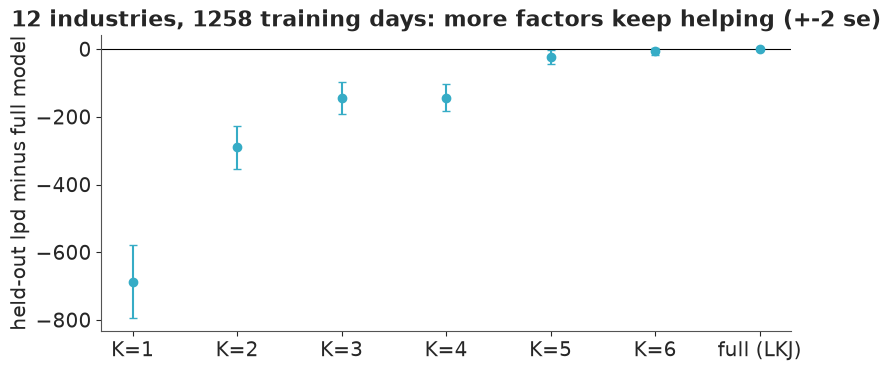

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.6))
rows = k_table.index[1:]
ax.errorbar(range(len(rows)), k_table.loc[rows, "diff vs full"], yerr=2 * k_table.loc[rows, "se of diff"],
            fmt="o", capsize=3)
ax.axhline(0, color="k", lw=0.8)
ax.set(xticks=range(len(rows)), xticklabels=rows, ylabel="held-out lpd minus full model",
       title="12 industries, 1258 training days: more factors keep helping (+-2 se)");

Four findings, all of them worth stating plainly:

1. **Dependence is almost everything.** Independent margins (K = 0) are thousands of nats worse
   than any model with a factor. A single market factor recovers most of the gap.
2. **More factors keep helping, and the full covariance is best on held-out data.** With 1258
   days and only 12 series there is plenty of data for all 66 correlations, and whatever
   structure a 3-factor model leaves out persists into the test period. K = 3 and 4 are about
   equally good. At K = 5-6 the factor model is within about two standard errors of the full model.
3. **The anchored fits get harder as K grows.** K = 4 and 5 printed dozens of divergences and
   ESS near 100 (the fourth and fifth factors are weak, and their anchors' loadings press against
   zero). Their held-out numbers are still sensible, since they are averages over draws of an
   identified $\Sigma$, but they are not fits to publish loadings from.
4. **LOO on the training days agrees on the big picture** (read the LOO column top to bottom),
   but at the top it ranks K = 6 slightly *above* the full model, which the held-out data do not. The difference is
   about 7 nats with a standard error of about 5: noise, as the comparison below shows.
   Every model also has a few training days with Pareto $k > 0.7$ (the last column), so the LOO
   estimates are themselves shaky on the most extreme days. For a time series, the held-out
   years are the comparison to believe. The difference at the top, with its standard error:

In [20]:
az.compare({k: loos[k] for k in ["K=5", "K=6", "full (LKJ)"]}, round_to=1)

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
K=6,0,0.0,0.0,NaN,,2 k̂ > 0.70,128.6,-15466.8,208.5,0.4
K=5,1,-5.9,4.7,0.9,,2 k̂ > 0.70,121.8,-15472.7,208.2,0.3
full (LKJ),2,-6.9,5.2,0.9,,3 k̂ > 0.70,142.3,-15473.7,209.5,0.3


So at $d = 12$ the factor model is a tool for **interpretation**, not better prediction. When
does it earn its keep as a predictor? When there are few days per dimension.

### 4.1 · Where factor models win: 30 industries, one year of data

The same library splits the market into 30 industries. Fit only on 2019 (252 days, so 8 days
per dimension instead of 105) and predict 2020-2024 again. The full covariance now has 435
correlations to learn from 252 days.

In [21]:
returns30 = industry_returns("ff_industries30_daily")
vol30 = np.sqrt(returns30.pow(2).ewm(alpha=0.06, adjust=False).mean().shift(1))
z30 = returns30 / vol30
Z30_train, Z30_test = z30.loc["2019"].to_numpy(), z30.loc[TEST].to_numpy()
names30 = list(returns30.columns)
print(f"30 industries: {len(Z30_train)} training days, {len(Z30_test)} test days")

heldout30, times30 = {}, {}
t0 = time.time()
with pm.Model() as full30:
    mu30 = pm.Normal("mu", 0.0, 0.2, shape=30)
    chol30, _, _ = pm.LKJCholeskyCov("chol", n=30, eta=2.0, sd_dist=pm.HalfNormal.dist(1.5), compute_corr=True)
    pm.MvNormal("z", mu30, chol=chol30, observed=Z30_train)
    idata30 = pm.sample(random_seed=RANDOM_SEED)
times30["full (LKJ)"] = time.time() - t0
heldout30["full (LKJ)"] = lpd_mvnormal(*full_draws(idata30, 200), Z30_test)
print(f"full: {times30['full (LKJ)']:.0f} s, divergences {int(idata30.sample_stats['diverging'].sum())}, "
      f"max r_hat {float(az.rhat(idata30.posterior['chol_corr']).max()):.3f}")
del idata30

for K in [1, 2, 3, 4, 6]:
    t0 = time.time()
    _, idata30, _ = fit_anchored(K, Z30_train, names30)
    times30[f"K={K}"] = time.time() - t0
    s30 = az.summary(idata30, var_names=["L_anchor", "L_free", "psi"])
    print(f"K = {K}: {times30[f'K={K}']:.0f} s, divergences {int(idata30.sample_stats['diverging'].sum())}, "
          f"max r_hat {s30['r_hat'].max():.3f}")
    heldout30[f"K={K}"] = lpd_mvnormal(*factor_draws(idata30, 200), Z30_test)
    del idata30

tbl30 = pd.DataFrame({
    "held-out lpd": {k: v.sum() for k, v in heldout30.items()},
    "diff vs full": {k: (v - heldout30["full (LKJ)"]).sum() for k, v in heldout30.items()},
    "se of diff": {k: np.sqrt(len(v)) * (v - heldout30["full (LKJ)"]).std() for k, v in heldout30.items()},
}).round(1)
tbl30

30 industries: 252 training days, 1258 test days


full: 5 s, divergences 0, max r_hat 1.005


K = 1: 3 s, divergences 0, max r_hat 1.007


K = 2: 4 s, divergences 0, max r_hat 1.015


K = 3: 4 s, divergences 0, max r_hat 1.004


K = 4: 5 s, divergences 0, max r_hat 1.043


K = 6: 5 s, divergences 0, max r_hat 1.037


,held-out lpd,diff vs full,se of diff
full (LKJ),-41822.9,0.0,0.0
K=1,-44105.6,-2282.7,150.6
K=2,-43013.5,-1190.7,141.6
K=3,-42061.7,-238.9,115.9
K=4,-41568.9,254.0,87.1
K=6,-41271.4,551.4,75.1


The ranking reverses. With 252 days for 30 series, a factor model with a handful of factors
predicts the next five years better than the full covariance, by several standard errors. A likely
reason: the full model spends its data on hundreds of correlations it cannot pin down, and its
LKJ prior shrinks every one of them towards *zero*, the wrong direction for industries that all
co-move. The factor model shrinks towards a **structure** instead.

The rule of thumb this illustrates: full covariance when days per dimension are plentiful;
factor structure (or a full covariance shrunk towards a factor structure) when they are not.
For a universe of hundreds of stocks the second case is the only case.

## 5 · Heavy tails: a Gaussian copula with Student-t margins

Every model so far is multivariate **Normal**, and section 1 showed that the standardised returns
are not. A *copula* separates the two questions: what does each industry's distribution look
like (its **margin**), and how are the industries tied together (the **copula**)? Sklar's
theorem says any joint distribution can be written this way.

The Gaussian copula with Student-t margins:

1. margins: $z_{i,t} \sim \text{Student-t}(\nu_i, \mu_i, \sigma_i)$ with CDF $F_i$;
2. **probability integral transform**: $u_{i,t} = F_i(z_{i,t})$ is Uniform(0, 1) if the margin is right;
3. **normal scores**: $x_{i,t} = \Phi^{-1}(u_{i,t})$ is standard Normal;
4. dependence: $x_t \sim \text{MvNormal}(0, R)$ with $R$ a *correlation* matrix.

The joint density of $z_t$ is the product of the margins times the copula density, and the copula
density is the MvNormal of the scores divided by their independent Normal densities:

$$
\log p(z_t) = \sum_i \log f_i(z_{i,t})\; +\; \log \text{MvNormal}(x_t \mid 0, R) - \sum_i \log \text{Normal}(x_{i,t} \mid 0, 1).
$$

In PyMC the margins are an ordinary observed `StudentT`, and the copula term is a
`pm.Potential`. Two numerical details matter:

* `pt.ndtri_exp(log_u)` computes $\Phi^{-1}(e^{\log u})$ stably from the **log**-CDF, so a
  probability of $10^{-12}$ does not underflow.
* The upper tail loses precision ($u = 1 - 10^{-12}$ rounds). Use the symmetry of the t:
  $x = -\operatorname{sign}(w)\,\Phi^{-1}\big(F(-|w|)\big)$ for the standardised $w = (z - \mu)/\sigma$.

**A PyMC 6.3 trap.** `pm.LKJCorr`'s documentation says to use it as a correlation matrix. Inside
a model, however, its value is the **Cholesky factor** of the correlation matrix (its default
transform, `CholeskyCorrTransform`, maps to the factor, and its `logp` expects one). Used as a
correlation matrix, it makes nutpie fail with "All initialization points failed". Treat it as
the Cholesky factor and form $R = L L^\top$ yourself.

**Estimating $\nu$.** With $\nu_i$ free inside the copula, each gradient needs the derivative
of the incomplete beta function with respect to its parameter. That makes each gradient several
times slower. We use the two-stage *inference functions for margins* approach (Joe 1997): fit
the 12 margins on their own (seconds), fix $\nu_i$ at their posterior means, and then fit
locations, scales and the copula jointly. Uncertainty about $\nu_i$ is not propagated. Section 7
returns to this.

In [22]:
with pm.Model(coords=coords) as margins_model:
    mu_m = pm.Normal("mu", 0.0, 0.2, dims="industry")
    sigma_m = pm.HalfNormal("sigma", 1.5, dims="industry")
    nu_m = pm.Gamma("nu", 2.0, 0.1, dims="industry")
    pm.StudentT("z", nu=nu_m, mu=mu_m, sigma=sigma_m, observed=Z_train, dims=("day", "industry"))
    idata_margins = pm.sample(random_seed=RANDOM_SEED)
nu_hat = idata_margins.posterior["nu"].mean(("chain", "draw")).values
print(f"max r_hat {float(az.summary(idata_margins)['r_hat'].max()):.3f}")
az.summary(idata_margins, var_names=["nu"])

max r_hat 1.004


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
nu[NoDur],7.15,1.37,5.3,9.6,3494,2933,1.00,0.024,0.024
nu[Durbl],6.93,1.36,5.1,9.4,2848,2816,1.00,0.026,0.027
nu[Manuf],6.07,1.03,4.7,7.9,3308,3083,1.00,0.018,0.018
nu[Enrgy],8.85,2.3,6.1,13,2725,2528,1.00,0.047,0.075
nu[Chems],8.15,1.75,5.8,11,3271,3042,1.00,0.031,0.034
nu[BusEq],4.21,0.53,3.4,5.1,3174,3066,1.00,0.0095,0.009
nu[Telcm],5.81,0.91,4.5,7.4,3445,2739,1.00,0.016,0.015
nu[Utils],8.36,1.98,5.9,12,2931,2760,1.00,0.038,0.044
nu[Shops],6.21,1.06,4.8,8.1,3716,3281,1.00,0.018,0.019
nu[Hlth],5.93,0.99,4.6,7.6,3224,2976,1.00,0.018,0.019


Tail indices of about 4-9: tails that are clearly heavier than Normal and vary by industry
(finance and tech are the heaviest). Now the copula:

In [23]:
with pm.Model(coords=coords) as copula_model:
    mu_c = pm.Normal("mu", 0.0, 0.2, dims="industry")
    sigma_c = pm.HalfNormal("sigma", 1.5, dims="industry")
    # 1. the margins
    pm.StudentT("z", nu=nu_hat, mu=mu_c, sigma=sigma_c, observed=Z_train, dims=("day", "industry"))
    # 2-3. probability integral transform and normal scores, tail-safe
    w = (Z_train - mu_c) / sigma_c
    log_u_lower = pm.logcdf(pm.StudentT.dist(nu=nu_hat, mu=0.0, sigma=1.0), -pt.abs(w))
    scores = -pt.sign(w) * pt.ndtri_exp(log_u_lower)
    # 4. the dependence: LKJCorr's in-model value is the Cholesky factor of R
    chol_R = pm.LKJCorr("chol_R", n=d, eta=2.0)
    pm.Deterministic("R", chol_R @ chol_R.T)
    pm.Potential(
        "gaussian_copula",
        pm.logp(pm.MvNormal.dist(mu=pt.zeros(d), chol=chol_R), scores).sum()
        - pm.logp(pm.Normal.dist(0.0, 1.0), scores).sum(),
    )

t0 = time.time()
with copula_model:
    idata_cop = pm.sample(random_seed=RANDOM_SEED, var_names=["mu", "sigma", "chol_R"])
time_cop = time.time() - t0
s_cop = az.summary(idata_cop, var_names=["mu", "sigma", "chol_R"])
s_cop = s_cop[s_cop["sd"] > 0]
print(f"{time_cop:.0f} s, divergences {int(idata_cop.sample_stats['diverging'].sum())}, "
      f"max r_hat {s_cop['r_hat'].max():.3f}, min ESS {s_cop['ess_bulk'].min():.0f}")

107 s, divergences 0, max r_hat 1.012, min ESS 582


A clean fit, but a slow one (see the timing): each gradient evaluates the Student-t CDF,
through the incomplete beta function, at 15,096 points.

### 5.1 · A contender: the multivariate Student-t

The copula makes each margin heavy-tailed but keeps Gaussian **dependence**. A Gaussian copula
has no *tail dependence*: however strong the correlation, the probability that industry B
crashes, given that A has, tends to zero as the crash gets more extreme. The **multivariate
Student-t** is the opposite compromise. It has one $\nu$ for everybody, but its heavy tails are
**shared**. It is a Normal whose whole covariance is scaled by a common random factor each day
(a common volatility shock), so extremes arrive together.

In [24]:
with pm.Model(coords=coords) as mvt_model:
    mu_t = pm.Normal("mu", 0.0, 0.2, dims="industry")
    chol_t, _, _ = pm.LKJCholeskyCov("chol", n=d, eta=2.0, sd_dist=pm.HalfNormal.dist(1.5), compute_corr=True)
    nu_t = pm.Gamma("nu", 2.0, 0.1)
    pm.MvStudentT("z", nu=nu_t, mu=mu_t, chol=chol_t, observed=Z_train, dims=("day", "industry"))
    idata_mvt = pm.sample(random_seed=RANDOM_SEED)
print(f"divergences {int(idata_mvt.sample_stats['diverging'].sum())}, "
      f"max r_hat {float(az.summary(idata_mvt, var_names=['mu', 'chol_stds', 'nu'])['r_hat'].max()):.3f}")
az.summary(idata_mvt, var_names=["nu"])

divergences 0, max r_hat 1.007


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
nu,5.95,0.322,5.5,6.5,4199,3112,1.00,0.005,0.005


### 5.2 · Which joint distribution predicts 2020-2024 best?

In [25]:
def lpd_copula(idata, Z, nu, n=400):
    post = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED)
    mu_, sig_ = post["mu"].values.T, post["sigma"].values.T
    chol_ = post["chol_R"].transpose("sample", ...).values
    lp = []
    for m_, s_, L_ in zip(mu_, sig_, chol_):
        w_ = (Z - m_) / s_
        x_ = -np.sign(w_) * special.ndtri_exp(stats.t.logcdf(-np.abs(w_), nu))
        lp.append(stats.t.logpdf(w_, nu).sum(1) - np.log(s_).sum()
                  + stats.multivariate_normal(np.zeros(len(m_)), L_ @ L_.T).logpdf(x_)
                  - stats.norm.logpdf(x_).sum(1))
    return special.logsumexp(np.array(lp), 0) - np.log(n)


def lpd_mvt(idata, Z, n=400):
    mu_, Sig_ = full_draws(idata, n)
    nu_ = az.extract(idata, num_samples=n, random_seed=RANDOM_SEED)["nu"].values
    lp = np.stack([stats.multivariate_t(m_, S_, df=v_).logpdf(Z) for m_, S_, v_ in zip(mu_, Sig_, nu_)])
    return special.logsumexp(lp, 0) - np.log(n)


post_m = az.extract(idata_margins, num_samples=400, random_seed=RANDOM_SEED)
lp_indep_t = stats.t.logpdf(Z_test[None], post_m["nu"].values.T[:, None], post_m["mu"].values.T[:, None],
                            post_m["sigma"].values.T[:, None]).sum(-1)
heldout["independent t margins"] = special.logsumexp(lp_indep_t, 0) - np.log(400)
heldout["Gaussian copula, t margins"] = lpd_copula(idata_cop, Z_test, nu_hat)
heldout["multivariate t"] = lpd_mvt(idata_mvt, Z_test)

show = ["K=0 (independent)", "independent t margins", "K=3", "full (LKJ)", "Gaussian copula, t margins",
        "multivariate t"]
pd.DataFrame({
    "held-out lpd": [heldout[k].sum() for k in show],
    "diff vs full Normal": [(heldout[k] - heldout["full (LKJ)"]).sum() for k in show],
    "se of diff": [np.sqrt(n_test) * (heldout[k] - heldout["full (LKJ)"]).std() for k in show],
}, index=show).round(1)

,held-out lpd,diff vs full Normal,se of diff
K=0 (independent),-22215.4,-5592.4,244.5
independent t margins,-21950.4,-5327.4,253.7
K=3,-16767.8,-144.8,23.2
full (LKJ),-16623.0,0.0,0.0
"Gaussian copula, t margins",-16355.1,267.9,85.5
multivariate t,-15683.2,939.9,124.1


* Heavy-tailed margins alone, without dependence, are hopeless. Dependence comes first.
* The Gaussian copula with t margins beats the full multivariate Normal by a few hundred nats.
  The only change is the margins, so this is what fat tails are worth one industry at a time.
* The multivariate t beats both by a much larger margin, even though its margins are cruder
  (a single $\nu$). What it adds is **shared** tails: the days when everything moves a lot at
  once. The EWMA filter does not remove those days, because it adapts only after the fact. On a
  day when the whole market is hit by news, every $z_{i,t}$ is large at once.

The tail-dependence picture makes that concrete. For a probability level $q$, take the
*conditional exceedance* $\chi(q) = P(U_j < q \mid U_i < q)$, averaged over all 66 pairs.
Under independence it equals $q$. For a Gaussian copula it falls to 0 as $q \to 0$. For a
t it levels off at a positive value.

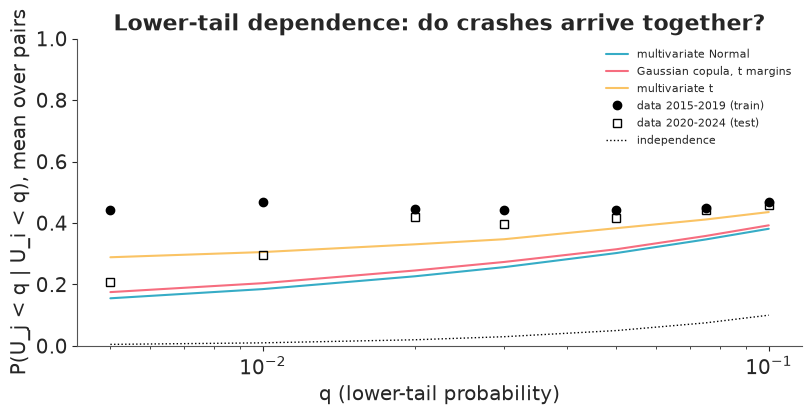

In [26]:
N_SIMS_PER_DRAW, N_DRAWS = 40, 1000


def simulate(kind):
    """Posterior predictive draws of standardised return vectors, (N_DRAWS * 40, d)."""
    out = []
    if kind == "multivariate Normal":
        mu_, Sig_ = full_draws(idata_mvn, N_DRAWS)
        for m_, S_ in zip(mu_, Sig_):
            out.append(rng.multivariate_normal(m_, S_, size=N_SIMS_PER_DRAW))
    elif kind == "multivariate t":
        mu_, Sig_ = full_draws(idata_mvt, N_DRAWS)
        nu_ = az.extract(idata_mvt, num_samples=N_DRAWS, random_seed=RANDOM_SEED)["nu"].values
        for m_, S_, v_ in zip(mu_, Sig_, nu_):
            g = rng.chisquare(v_, size=(N_SIMS_PER_DRAW, 1)) / v_
            out.append(m_ + rng.multivariate_normal(np.zeros(d), S_, size=N_SIMS_PER_DRAW) / np.sqrt(g))
    elif kind == "Gaussian copula, t margins":
        post = az.extract(idata_cop, num_samples=N_DRAWS, random_seed=RANDOM_SEED)
        for m_, s_, L_ in zip(post["mu"].values.T, post["sigma"].values.T, post["chol_R"].transpose("sample", ...).values):
            x_ = rng.standard_normal((N_SIMS_PER_DRAW, d)) @ L_.T
            out.append(m_ + s_ * stats.t.ppf(stats.norm.cdf(x_), nu_hat))
    elif kind == "independent t margins":
        post = az.extract(idata_margins, num_samples=N_DRAWS, random_seed=RANDOM_SEED)
        for m_, s_, v_ in zip(post["mu"].values.T, post["sigma"].values.T, post["nu"].values.T):
            out.append(m_ + s_ * stats.t.rvs(v_, size=(N_SIMS_PER_DRAW, d), random_state=rng))
    return np.concatenate(out)


MODELS = ["independent t margins", "multivariate Normal", "Gaussian copula, t margins", "multivariate t"]
sims = {k: simulate(k) for k in MODELS}


def chi_curve(Z, qs):
    U = (stats.rankdata(Z, axis=0) - 0.5) / len(Z)          # empirical PIT per column
    low = [(U < q_) for q_ in qs]
    iu = np.triu_indices(Z.shape[1], 1)
    return np.array([((lo.T.astype(float) @ lo)[iu] / lo.sum(0)[iu[0]]).mean() for lo in low])


qs = np.array([0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1])
fig, ax = plt.subplots(figsize=(8, 4))
for k, c in zip(MODELS[1:], ["C0", "C1", "C2"]):
    ax.plot(qs, chi_curve(sims[k], qs), "-", color=c, label=k)
ax.plot(qs, chi_curve(Z_train, qs), "ko", label="data 2015-2019 (train)")
ax.plot(qs, chi_curve(Z_test, qs), "ks", mfc="none", label="data 2020-2024 (test)")
ax.plot(qs, qs, "k:", lw=1, label="independence")
ax.set(xscale="log", xlabel="q (lower-tail probability)", ylabel="P(U_j < q | U_i < q), mean over pairs",
       title="Lower-tail dependence: do crashes arrive together?", ylim=(0, 1))
ax.legend(fontsize=8);

This is the core of the notebook in one figure. In the training years, when one industry has a
1-in-100 day, the average other industry has one too almost half the time, and that share barely
changes as the threshold moves further into the tail. In the test years it is about 0.4 down to
$q$ = 2% and lower beyond (0.3 at 1%, 0.2 at 0.5%). The smallest $q$ rests on a handful of days
(0.5% of 1258 is 6 days per industry), so those points are noisy. The multivariate Normal and the
Gaussian copula share Gaussian dependence, so their curves nearly coincide, and both fall away
as $q$ shrinks, below both data sets. The multivariate t sits higher and flatter. It matches the
test data near 1% but is still below the training data, the data it was fitted to, at every $q$.

## 6 · The decision: backtesting on 2020-2024

Two questions from the risk manager, both answered with the posterior predictive draws above and
scored on the five held-out years. Forecasts for day $t$ use only $s_{i,t}$, which is known the
evening before.

**(a) Value-at-Risk.** For an equally weighted portfolio of the 12 industries, the 1% VaR of day
$t$ is the 1% quantile of $\sum_i w_i s_{i,t} z_i$ under the predictive distribution. A good
model is breached on about 1% of days: 12.6 of 1258.

**(b) Joint crashes.** How many days in 2020-2024 did at least $k$ of the 12 industries fall
more than 2 of their own (EWMA) standard deviations? The predicted number is $1258 \times P(N \ge k)$,
where $N$ is the number of industries with $z_i < -2$.

In [27]:
weights = np.full(d, 1 / d)
portfolio = R_test @ weights


def var_forecast(Zs, level):
    out = np.empty(n_test)
    for start in range(0, n_test, 100):                     # chunks keep memory small
        block = Zs @ (weights * S_test[start:start + 100]).T
        out[start:start + 100] = np.quantile(block, level, axis=0)
    return out


ks = [1, 3, 6, 9, 12]
N_obs_test, N_obs_train = (Z_test < -2).sum(1), (Z_train < -2).sum(1)
rows, var1 = [], {}
for k in MODELS:
    var1[k] = var_forecast(sims[k], 0.01)
    var5 = var_forecast(sims[k], 0.05)
    N_sim = (sims[k] < -2).sum(1)
    rows.append([(portfolio < var1[k]).sum(), (portfolio < var5).sum()] + [n_test * (N_sim >= k_).mean() for k_ in ks])
rows.append([0.01 * n_test, 0.05 * n_test] + [(N_obs_test >= k_).sum() for k_ in ks])
backtest = pd.DataFrame(rows, index=MODELS + ["OBSERVED (target for VaR)"],
                        columns=["1% VaR breaches", "5% VaR breaches"] + [f"days N>={k_}" for k_ in ks]).round(1)
print(f"training period, observed days with N >= k: {[(N_obs_train >= k_).sum() for k_ in ks]} (k = {ks})")
backtest

training period, observed days with N >= k: [np.int64(185), np.int64(47), np.int64(29), np.int64(17), np.int64(2)] (k = [1, 3, 6, 9, 12])


,1% VaR breaches,5% VaR breaches,days N>=1,days N>=3,days N>=6,days N>=9,days N>=12
independent t margins,189.0,287.0,333.8,4.1,0.0,0.0,0.0
multivariate Normal,26.0,70.0,169.7,41.5,11.3,1.7,0.1
"Gaussian copula, t margins",17.0,70.0,179.2,49.5,14.4,3.4,0.2
multivariate t,15.0,70.0,159.3,53.8,20.8,6.3,0.5
OBSERVED (target for VaR),12.6,62.9,201.0,59.0,24.0,15.0,6.0


Reading the table (predicted counts in the model rows, what happened in the last row):

* **Ignoring dependence is dangerous.** With independent margins the model believes the portfolio
  is much more diversified than it is, so its VaR is far too shallow and is breached on a large
  fraction of days. It predicts almost no day on which even three industries crash together.
* **The multivariate Normal breaches its 1% VaR about twice as often as it should.** At the 5%
  level all three dependent models are close (about 70 breaches against 63 expected). Normality
  fails in the far tail, which is where a 1% VaR lives.
* **The Gaussian copula** repairs part of that with its heavy margins; **the multivariate t**
  gets closest to the nominal 12.6 breaches.
* **Joint crashes are under-predicted by every model.** Days with 9 or more industries down by
  2 sigma, and the handful of days on which *all 12* were, happened two to twelve times more often than
  even the multivariate t predicts. The line printed above the table shows it was already true in
  the training data: this is a model failure a posterior predictive check could have caught
  before 2020, not bad luck in the test period.

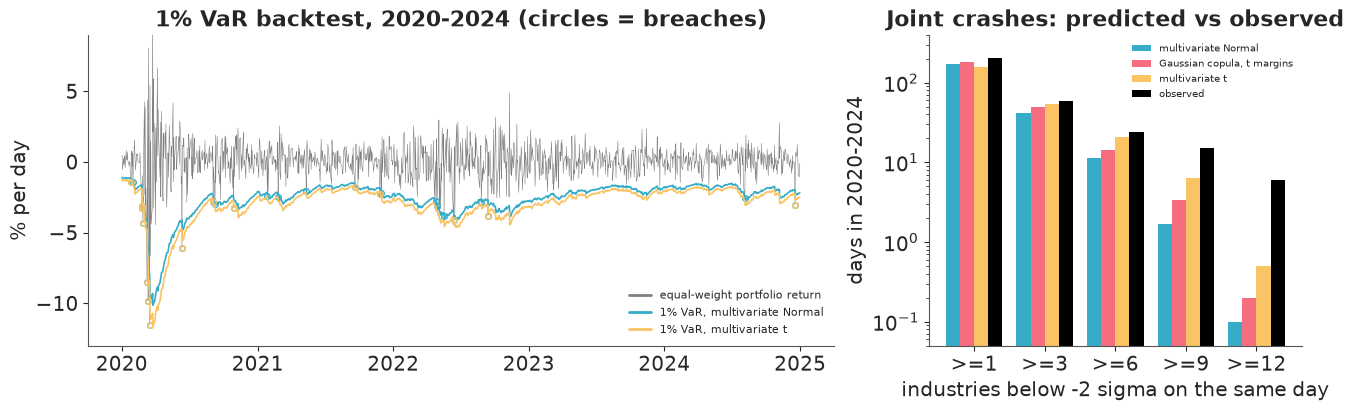

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
ax = axes[0]
dates = returns.loc[TEST].index
ax.plot(dates, portfolio, lw=0.4, color="0.5", label="equal-weight portfolio return")
for k, c in [("multivariate Normal", "C0"), ("multivariate t", "C2")]:
    ax.plot(dates, var1[k], lw=1.2, color=c, label=f"1% VaR, {k}")
    hit = portfolio < var1[k]
    ax.plot(dates[hit], portfolio[hit], "o", ms=4, mfc="none", color=c)
ax.set(ylim=(-13, 9), ylabel="% per day", title="1% VaR backtest, 2020-2024 (circles = breaches)")
for line in ax.legend(fontsize=8, loc="lower right").get_lines():
    line.set_linewidth(2)
ax = axes[1]
x = np.arange(len(ks))
for j, k in enumerate(MODELS[1:]):
    ax.bar(x + (j - 1.5) * 0.2, backtest.loc[k, [f"days N>={k_}" for k_ in ks]], width=0.2, label=k)
ax.bar(x + 1.5 * 0.2, backtest.loc["OBSERVED (target for VaR)", [f"days N>={k_}" for k_ in ks]],
       width=0.2, color="k", label="observed")
ax.set(xticks=x, xticklabels=[f">={k_}" for k_ in ks], yscale="log", ylim=(0.05, 400),
       xlabel="industries below -2 sigma on the same day", ylabel="days in 2020-2024",
       title="Joint crashes: predicted vs observed")
ax.legend(fontsize=7);

Where do the breaches fall? About a third of them are in January-March 2020 (the VaR lines
plunge only after the EWMA volatility has caught up). The rest are sharp one-day sell-offs scattered
over the five years. What those days have in common:

In [29]:
hit_normal = portfolio < var1["multivariate Normal"]
print(f"industries below -2 sigma: {N_obs_test[hit_normal].mean():.1f} on average on the "
      f"{hit_normal.sum()} Normal-VaR breach days, versus {N_obs_test.mean():.2f} on an average test day")
print("breach dates:", ", ".join(f"{t:%Y-%m-%d}" for t in dates[hit_normal]))

industries below -2 sigma: 8.8 on average on the 26 Normal-VaR breach days, versus 0.43 on an average test day
breach dates: 2020-01-27, 2020-01-31, 2020-02-24, 2020-02-25, 2020-02-27, 2020-03-09, 2020-03-12, 2020-03-16, 2020-06-11, 2020-09-03, 2020-09-08, 2020-10-28, 2021-01-27, 2021-02-25, 2021-05-12, 2021-09-20, 2021-11-26, 2021-11-30, 2022-04-26, 2022-04-29, 2022-05-18, 2022-06-13, 2022-08-26, 2022-09-13, 2024-08-05, 2024-12-18


The breach days are systemic days: on a typical breach, most of the 12 industries fell by more
than two of their own expected standard deviations at once. The right panel above shows the
same thing from the other side. The dependent models roughly agree about ordinary bad days (one
industry down 2 sigma), and as the event becomes more systemic they spread apart and all fall
short of what happened.

**What would fix it?** The pattern points at a *common* volatility shock that the per-industry
EWMA filter adapts to only after the fact. The multivariate t's shared scale is a crude version
of that, and it helps. Better candidates are a t-copula (shared tails and industry-specific
margins), a factor model whose factor has stochastic volatility, or a multivariate GARCH.

## 7 · Summary

| Question | Model | Lesson |
|---|---|---|
| How do 12 industries co-move? | `MvNormal` + `LKJCholeskyCov` | Fast and clean at $d=12$; LKJ($\eta$) gets tighter as $d$ grows; $d(d-1)/2$ correlations |
| Can a few common shocks explain it? | factor model, $\Lambda\Lambda^\top + \text{diag}(\psi^2)$ | Loadings are not identified: sign flips give r_hat about 1.7, rotations give loadings that average to zero with a low ESS, and the covariance stays fine |
| How do we identify it? | anchored lower-triangular / Procrustes alignment | Naive ordering creates boundary modes; choose anchors by pivoted QR and start at the ML solution, or sample freely and rotate each draw to a varimax reference |
| How many factors? | held-out lpd and LOO | At 105 days per dimension the full covariance wins; at 8 days per dimension (30 industries, one year) factors win |
| Heavy tails? | Gaussian copula with t margins (by hand) and the multivariate t | Heavier margins help; *shared* tails help more; Gaussian dependence has no tail dependence |
| Is the book safe? | VaR and joint-crash backtest | Normal: about 2x the nominal 1% breaches; all models under-predict systemic days |

## Try it yourself

1. **A t-copula.** Replace the Gaussian copula by a Student-t copula: the scores become
   $t_{\nu_c}^{-1}(u)$ and the copula density is $\text{MvStudentT}_{\nu_c}(x \mid 0, R) / \prod_i t_{\nu_c}(x_i)$.
   The t quantile function has no PyTensor implementation, so think about how to get the scores
   (a fixed $\nu_c$ and a precomputed interpolation table is one honest shortcut). Does it close
   the gap to the data in the tail-dependence figure and on the "N >= 9" days?
2. **Free the tails.** Fit the copula with $\nu_i$ as free parameters (remove the two-stage
   shortcut), time it, and compare the held-out lpd and the $\nu_i$ with the two-stage fit. Does
   the joint model find different tail indices from the margins-only fit, and why might it?
3. **Shrink towards the factors.** Build a hybrid for the 30-industry, one-year case:
   $\Sigma = \Lambda\Lambda^\top + \text{diag}(\psi^2) + \tau^2 E$, where $E$ is a small full
   covariance matrix (an `LKJCholeskyCov` scaled by a `HalfNormal` $\tau$). Does it beat both of
   its parents on the held-out lpd? What does the posterior of $\tau$ say about how much
   structure the factors miss?

**References.** Bollerslev (1990), constant conditional correlation GARCH · Lewandowski,
Kurowicka & Joe (2009), the LKJ distribution · Geweke & Zhou (1996) and Lopes & West (2004),
Bayesian factor analysis and its identification · Joe (1997), *Multivariate Models and
Dependence Concepts* (copulas, IFM) · McNeil, Frey & Embrechts (2015), *Quantitative Risk
Management* (tail dependence, VaR backtesting).